## Ekstrakcja topologii

### Importy

In [46]:
from __future__ import annotations

import cv2
import numpy as np
from pathlib import Path

from skimage.morphology import skeletonize
from coronary_analysis.utils import show_image
import sknw
from skimage import morphology, measure

import torch
from coronary_analysis.models.segmentation import CoronaryUNet
from coronary_analysis.transforms.transforms import get_val_transforms

### Konfiguracja zmiennych środowiskowych

In [47]:
USE_GROUND_TRUTH: bool = True
SAMPLE_ID: int = 100
DCA1_DIR = Path("raw_datasets/DCA1/Database_134_Angiograms")
MODEL_PATH = Path("../models/best_coronary_unet.pth")
IMG_SIZE: int = 250
THRESHOLD: float = 0.5
MIN_OBJECT_SIZE: int = 50
MAX_HOLE_SIZE: int = 50
CLOSING_DISK_RADIUS: float = 2
MIN_BRANCH_LENGTH = 15
COLLINEARITY_THRESHOLD = 30

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Wczytanie danych

### Wczytanie pliku PGM w skali szarości

In [48]:
def _load_pgm(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f"File not found: {path}")

    return image

### Wczytanie obrazu oraz binaryzacja

In [49]:
def load_sample(
    sample_id: int, ground_truth: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    image = _load_pgm(DCA1_DIR / f"{sample_id}.pgm")

    if ground_truth:
        raw = _load_pgm(DCA1_DIR / f"{sample_id}_gt.pgm")
        mask = (raw > 0).astype(np.uint8)
    else:
        mask = _predict_mask(image)

    return image, mask

### Uruchomienie modelu segmentacji i zwrócenie maski binarnej

In [50]:
def _predict_mask(image: np.ndarray) -> np.ndarray:
    model = CoronaryUNet(encoder_name="resnet34").to(device)
    state = torch.load(str(MODEL_PATH), map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()

    transform = get_val_transforms(IMG_SIZE)
    augmented = transform(image=image, mask=np.zeros_like(image))

    img_tensor = (
        torch.from_numpy(augmented["image"]).float().unsqueeze(0).unsqueeze(0) / 255.0
    ).to(device)

    with torch.no_grad():
        probs = model.predict_proba(img_tensor)
        pred = (probs > THRESHOLD).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    h, w = image.shape[:2]
    if pred_np.shape != (h, w):
        pred_np = cv2.resize(pred_np, (w, h), interpolation=cv2.INTER_NEAREST)

    return pred_np

### Wizualizacja wczytanych danych

Image: shape=(300, 300), dtype=uint8
Mask: shape=(300, 300), dtype=uint8, unique=[0 1]


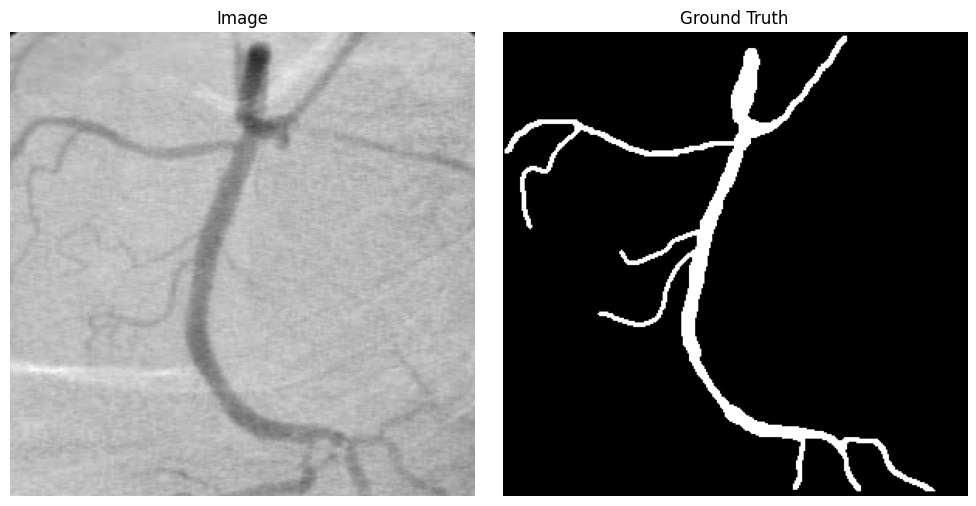

In [51]:
image, raw_mask = load_sample(SAMPLE_ID, ground_truth=USE_GROUND_TRUTH)

source_label = "Ground Truth" if USE_GROUND_TRUTH else "Model Prediction"

print(f"Image: shape={image.shape}, dtype={image.dtype}")
print(
    f"Mask: shape={raw_mask.shape}, dtype={raw_mask.dtype}, "
    f"unique={np.unique(raw_mask)}"
)

show_image(image, raw_mask, titles=["Image", source_label])

### Wstępne przetwarzanie danych

In [52]:
def clean_mask(mask: np.ndarray) -> dict[str, np.ndarray]:
    binary = mask.astype(bool)

    closed = (
        morphology.closing(binary, morphology.disk(CLOSING_DISK_RADIUS))
        if CLOSING_DISK_RADIUS > 0
        else binary
    )

    no_holes = morphology.remove_small_holes(closed, max_size=MAX_HOLE_SIZE)

    final = morphology.remove_small_objects(no_holes, max_size=MIN_OBJECT_SIZE)

    return {
        "input": binary,
        "closed": closed,
        "no_holes": no_holes,
        "final": final,
    }

### Liczba połączonych elementów w masce

In [53]:
def _count_components(mask: np.ndarray) -> int:
    return measure.label(mask).max()

### Wizualizacja przeprocesowanych danych

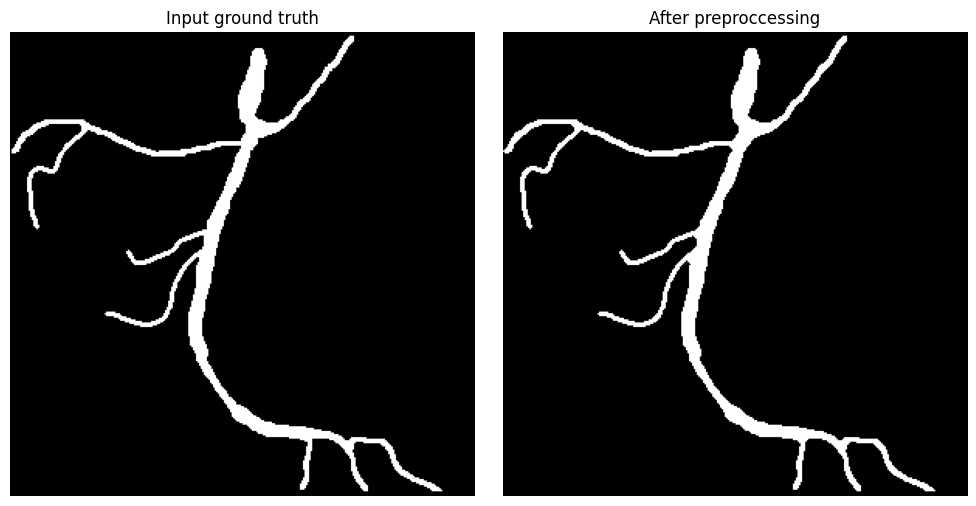

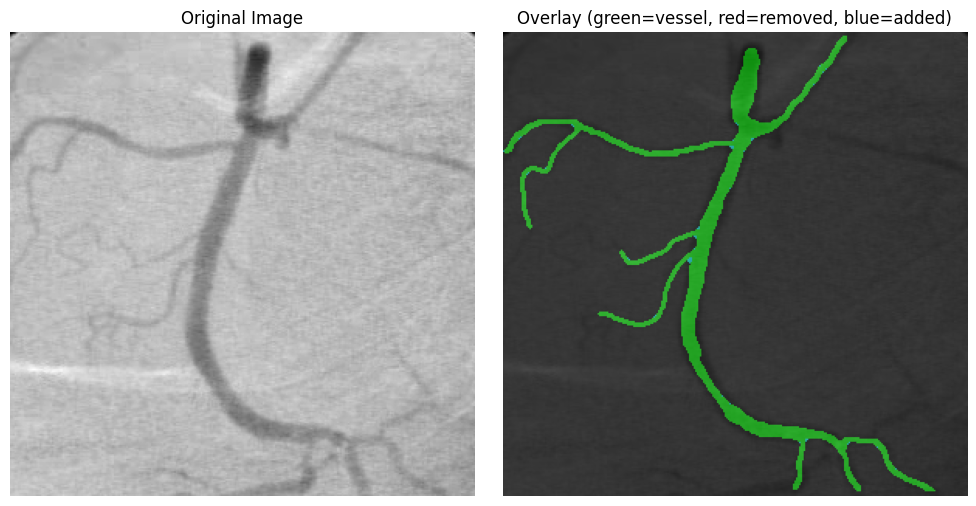

In [54]:
stages = clean_mask(raw_mask)
mask_clean = stages["final"]

removed = stages["input"] & ~stages["final"]
added = stages["final"] & ~stages["input"]

overlay = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
overlay[stages["final"], 1] += 0.5
overlay[removed, 0] += 0.5
overlay[added, 2] += 0.5
overlay = np.clip(overlay, 0, 1)

show_image(
    stages["input"].astype(np.uint8),
    stages["final"].astype(np.uint8),
    titles=[
        "Input ground truth" if USE_GROUND_TRUTH else "Input segmentation",
        "After preproccessing",
    ],
)

show_image(
    image,
    overlay,
    titles=["Original Image", "Overlay (green=vessel, red=removed, blue=added)"],
    cmap=["gray", None],
)

## Szkieletyzacja

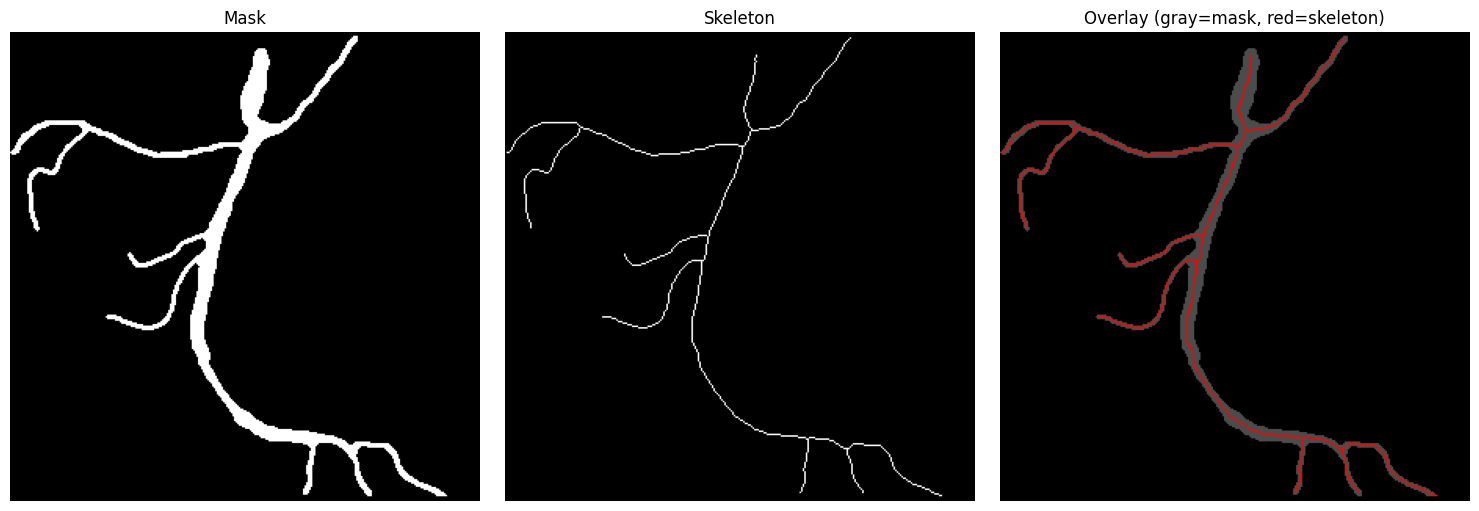

In [55]:
skeleton = skeletonize(mask_clean)

overlay = np.zeros((*mask_clean.shape, 3))
overlay[mask_clean, :] = [0.3, 0.3, 0.3]
overlay[skeleton, :] = [1, 0, 0]

show_image(
    mask_clean.astype(np.uint8),
    skeleton.astype(np.uint8),
    overlay,
    titles=["Mask", "Skeleton", "Overlay (gray=mask, red=skeleton)"],
    cmap=["gray", "gray", None],
)

### Rysowanie punktów

In [56]:
def _draw_points(
    base: np.ndarray, points: np.ndarray, color: tuple, radius: int = 3
) -> np.ndarray:
    img = base.copy()

    for r, c in points:
        cv2.circle(img, (int(c), int(r)), radius, color, -1)

    return img

### Klasyfikacja pikseli

In [57]:
def classify_skeleton_pixels(skel: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]], dtype=np.uint8)

    filtered = cv2.filter2D(skel.astype(np.uint8), -1, kernel)
    endpoints = np.argwhere(filtered == 11)
    junctions = np.argwhere(filtered >= 13)

    return endpoints, junctions


endpoints, junctions = classify_skeleton_pixels(skeleton)
print(f"Punkty końcowe : {len(endpoints)}")
print(f"Rozgałęzienia  : {len(junctions)}")

Punkty końcowe : 9
Rozgałęzienia  : 20


### Wizualizacja punktów końcowych

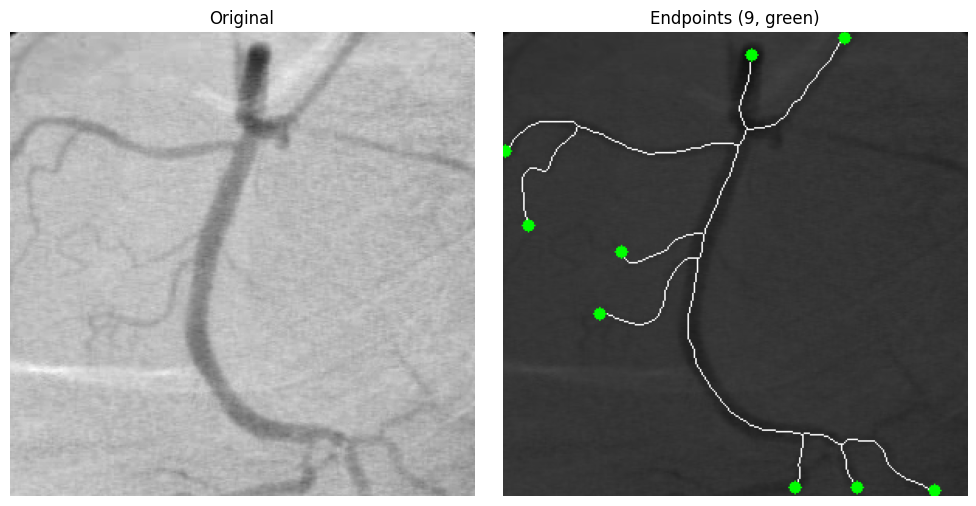

In [58]:
vis_ep = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_ep[skeleton, :] = [1, 1, 1]
vis_ep = _draw_points(vis_ep, endpoints, (0, 1, 0), radius=4)

show_image(
    image,
    vis_ep,
    titles=["Original", f"Endpoints ({len(endpoints)}, green)"],
    cmap=["gray", None],
)

### Wizualizacja rozgałęzień

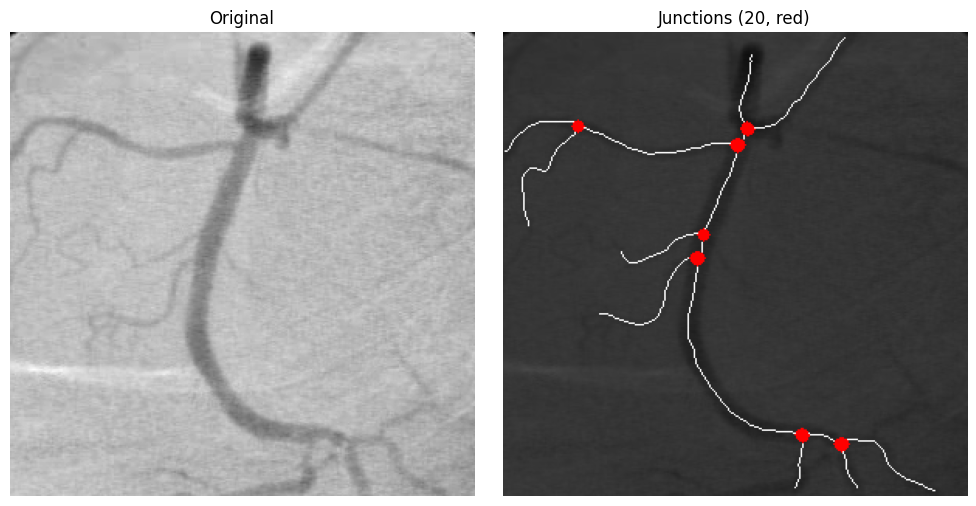

In [59]:
vis_junc = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_junc[skeleton, :] = [1, 1, 1]
vis_junc = _draw_points(vis_junc, junctions, (1, 0, 0), radius=4)

show_image(
    image,
    vis_junc,
    titles=["Original", f"Junctions ({len(junctions)}, red)"],
    cmap=["gray", None],
)

### Pruning

In [60]:
def prune_skeleton(skel: np.ndarray) -> np.ndarray:
    pruned = skel.copy()

    while True:
        eps, _ = classify_skeleton_pixels(pruned)
        if len(eps) == 0:
            break

        changed = False
        for r, c in eps:
            branch = [(r, c)]
            cur_r, cur_c = r, c

            for _ in range(MIN_BRANCH_LENGTH):
                found = False
                for dr in (-1, 0, 1):
                    for dc in (-1, 0, 1):
                        if dr == 0 and dc == 0:
                            continue
                        nr, nc = cur_r + dr, cur_c + dc
                        if (
                            0 <= nr < pruned.shape[0]
                            and 0 <= nc < pruned.shape[1]
                            and pruned[nr, nc]
                            and (nr, nc) not in branch
                        ):
                            branch.append((nr, nc))
                            cur_r, cur_c = nr, nc
                            found = True
                            break
                    if found:
                        break
                if not found:
                    break

            if len(branch) < MIN_BRANCH_LENGTH:
                for pr, pc in branch:
                    pruned[pr, pc] = False
                changed = True

        if not changed:
            break

    return pruned


skeleton_pruned = prune_skeleton(skeleton)
ep_pruned, junc_pruned = classify_skeleton_pixels(skeleton_pruned)

print("─" * 55)
print(f"{'':30} {'Before':>8} {'After':>8}")
print("─" * 55)
print(f"{'Endpoints':<30} {len(endpoints):>8} {len(ep_pruned):>8}")
print(f"{'Junctions':<30} {len(junctions):>8} {len(junc_pruned):>8}")
print(
    f"{'Skeleton pixels':<30} {int(skeleton.sum()):>8} {int(skeleton_pruned.sum()):>8}"
)
print("─" * 55)

───────────────────────────────────────────────────────
                                 Before    After
───────────────────────────────────────────────────────
Endpoints                             9        9
Junctions                            20       20
Skeleton pixels                     879      879
───────────────────────────────────────────────────────


### Wizualizacja pruningu

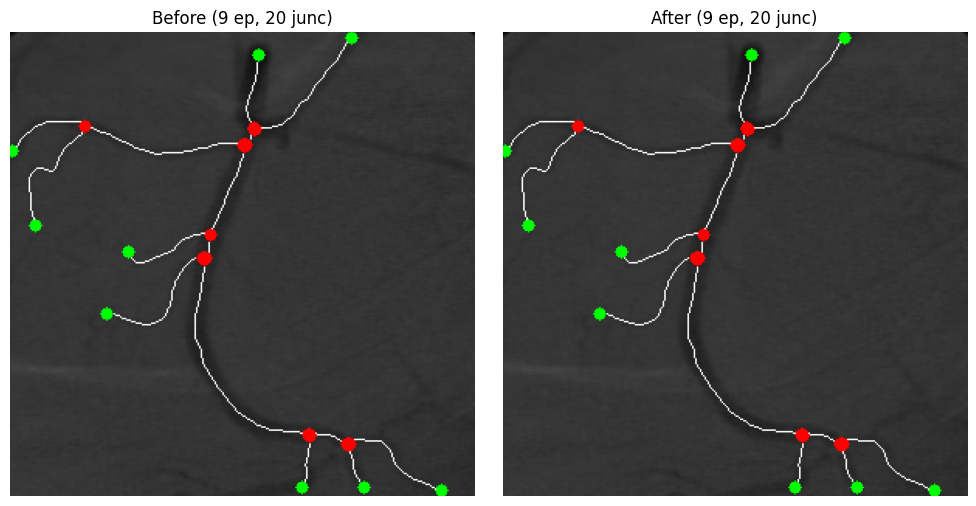

In [61]:
vis_before = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_before[skeleton, :] = [1, 1, 1]
vis_before = _draw_points(vis_before, endpoints, (0, 1, 0), radius=4)
vis_before = _draw_points(vis_before, junctions, (1, 0, 0), radius=4)

vis_after = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_after[skeleton_pruned, :] = [1, 1, 1]
vis_after = _draw_points(vis_after, ep_pruned, (0, 1, 0), radius=4)
vis_after = _draw_points(vis_after, junc_pruned, (1, 0, 0), radius=4)

show_image(
    vis_before,
    vis_after,
    titles=[
        f"Before ({len(endpoints)} ep, {len(junctions)} junc)",
        f"After ({len(ep_pruned)} ep, {len(junc_pruned)} junc)",
    ],
    cmap=[None, None],
)

### Klasyfikacja rozgałęzień

In [62]:
def _branch_direction(
    skel: np.ndarray,
    start_r: int,
    start_c: int,
    junc_r: int,
    junc_c: int,
    steps: int = 8,
) -> np.ndarray:
    path = [(start_r, start_c)]
    visited = {(junc_r, junc_c), (start_r, start_c)}
    cur_r, cur_c = start_r, start_c

    for _ in range(steps - 1):
        found = False
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                nr, nc = cur_r + dr, cur_c + dc
                if (
                    0 <= nr < skel.shape[0]
                    and 0 <= nc < skel.shape[1]
                    and skel[nr, nc]
                    and (nr, nc) not in visited
                ):
                    path.append((nr, nc))
                    visited.add((nr, nc))
                    cur_r, cur_c = nr, nc
                    found = True
                    break
            if found:
                break
        if not found:
            break

    if len(path) < 2:
        return np.array([0.0, 0.0])

    direction = np.array([path[-1][0] - junc_r, path[-1][1] - junc_c], dtype=np.float64)
    norm = np.linalg.norm(direction)
    return direction / norm if norm > 0 else direction


def _angle_between(v1: np.ndarray, v2: np.ndarray) -> float:
    cos = np.clip(np.dot(v1, v2), -1, 1)
    return np.degrees(np.arccos(cos))

In [63]:
def classify_junctions(skel: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    endpoints, all_junctions = classify_skeleton_pixels(skel)

    bifurcations = []
    crossings = []

    for r, c in all_junctions:
        neighbors = [
            (r + dr, c + dc)
            for dr in (-1, 0, 1)
            for dc in (-1, 0, 1)
            if not (dr == 0 and dc == 0)
            and 0 <= r + dr < skel.shape[0]
            and 0 <= c + dc < skel.shape[1]
            and skel[r + dr, c + dc]
        ]

        if len(neighbors) < 4:
            bifurcations.append((r, c))
            continue

        directions = [_branch_direction(skel, nr, nc, r, c) for nr, nc in neighbors]
        directions = [d for d in directions if np.linalg.norm(d) > 0]

        is_crossing = any(
            _angle_between(directions[i], directions[j]) >= 180 - COLLINEARITY_THRESHOLD
            for i in range(len(directions))
            for j in range(i + 1, len(directions))
        )

        (crossings if is_crossing else bifurcations).append((r, c))

    def _to_array(lst):
        return np.array(lst).reshape(-1, 2) if lst else np.empty((0, 2), dtype=int)

    return endpoints, _to_array(bifurcations), _to_array(crossings)


ep_final, bif_final, cross_final = classify_junctions(skeleton_pruned)

print(f"Endpoints    : {len(ep_final)}")
print(f"Bifurcations : {len(bif_final)}")
print(f"Crossings    : {len(cross_final)}")

Endpoints    : 9
Bifurcations : 18
Crossings    : 2


### Wizualizacja klasyfikacji

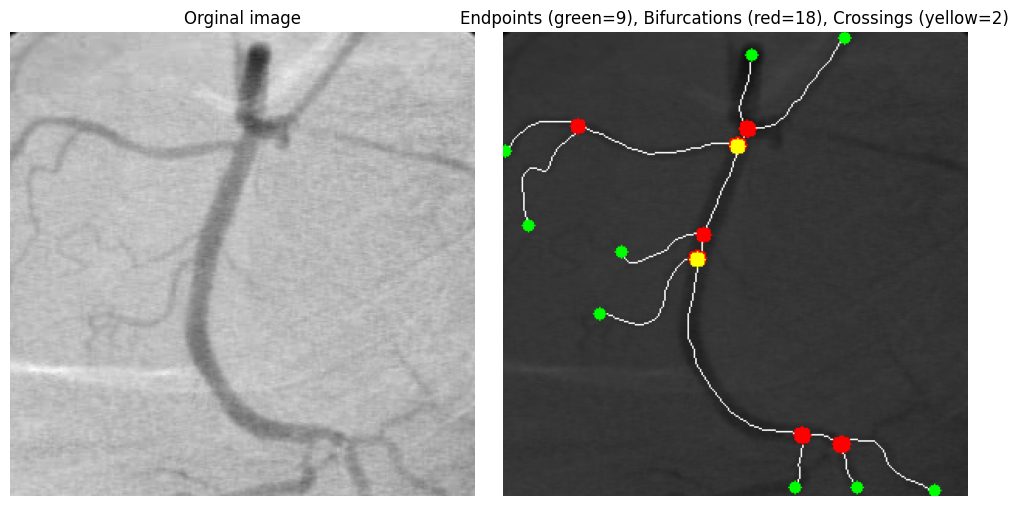

In [64]:
vis_class = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4
vis_class[skeleton_pruned, :] = [1, 1, 1]
vis_class = _draw_points(vis_class, ep_final, (0, 1, 0), radius=4)
vis_class = _draw_points(vis_class, bif_final, (1, 0, 0), radius=5)
vis_class = _draw_points(vis_class, cross_final, (1, 1, 0), radius=5)

show_image(
    image,
    vis_class,
    titles=[
        "Orginal image",
        f"Endpoints (green={len(ep_final)}), "
        f"Bifurcations (red={len(bif_final)}), "
        f"Crossings (yellow={len(cross_final)})",
    ],
    cmap=["gray", None],
)

## Budowa grafu

In [65]:
graph = sknw.build_sknw(skeleton_pruned.astype(np.uint16))

print(f"Nodes : {graph.number_of_nodes()}")
print(f"Edges : {graph.number_of_edges()}")

for i, (nid, data) in enumerate(graph.nodes(data=True)):
    if i >= 5:
        break
    pos = data["o"]
    deg = graph.degree(nid)
    ntype = "endpoint" if deg == 1 else f"junction (degree={deg})"
    print(f"  Node {nid}: pos=({pos[0]:.0f}, {pos[1]:.0f}), {ntype}")

Nodes : 16
Edges : 15
  Node 0: pos=(4, 220), endpoint
  Node 1: pos=(15, 160), endpoint
  Node 2: pos=(61, 48), junction (degree=3)
  Node 3: pos=(63, 157), junction (degree=3)
  Node 4: pos=(73, 151), junction (degree=3)


### Wizualizacja grafu

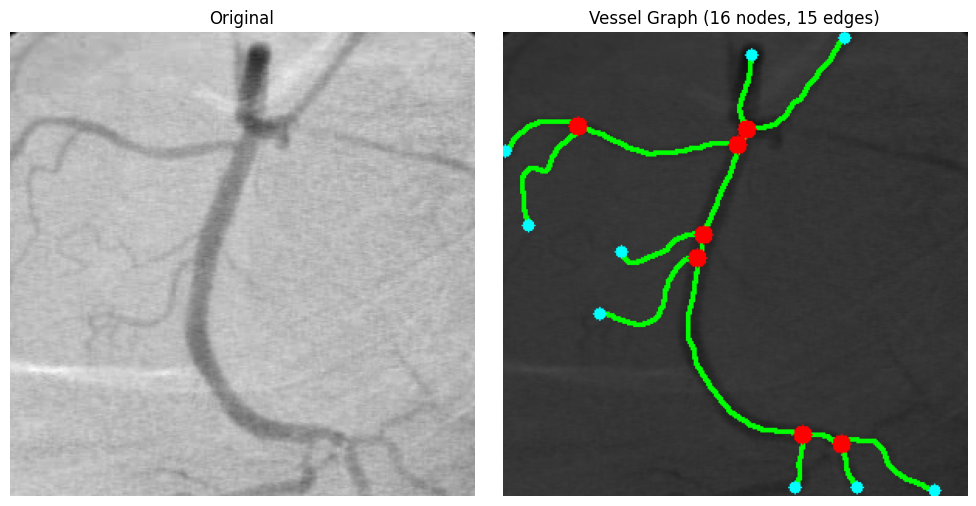

In [66]:
vis_graph = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4

for s, e in graph.edges():
    pts = graph[s][e]["pts"]
    for k in range(len(pts) - 1):
        cv2.line(
            vis_graph,
            (int(pts[k, 1]), int(pts[k, 0])),
            (int(pts[k + 1, 1]), int(pts[k + 1, 0])),
            (0, 1, 0),
            2,
        )

for nid, data in graph.nodes(data=True):
    pos = data["o"]
    deg = graph.degree(nid)
    color = (1, 0, 0) if deg >= 3 else (0, 1, 1)
    radius = 6 if deg >= 3 else 4
    cv2.circle(vis_graph, (int(pos[1]), int(pos[0])), radius, color, -1)

show_image(
    image,
    vis_graph,
    titles=[
        "Original",
        f"Vessel Graph ({graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges)",
    ],
    cmap=["gray", None],
)

### Klasyfikacja węzłów grafu

In [67]:
def _edge_direction(
    graph, node_id: int, neighbor_id: int, steps: int = 8
) -> np.ndarray:
    pts = graph[node_id][neighbor_id]["pts"]
    node_pos = graph.nodes[node_id]["o"]

    dist_start = np.linalg.norm(pts[0] - node_pos)
    dist_end = np.linalg.norm(pts[-1] - node_pos)
    if dist_end < dist_start:
        pts = pts[::-1]

    end_idx = min(steps, len(pts) - 1)
    direction = pts[end_idx] - pts[0]
    norm = np.linalg.norm(direction)
    return direction / norm if norm > 0 else direction


def classify_graph_nodes(graph) -> dict[int, str]:
    labels = {}

    for nid in graph.nodes():
        deg = graph.degree(nid)

        if deg <= 1:
            labels[nid] = "endpoint"
            continue

        if deg <= 3:
            labels[nid] = "bifurcation"
            continue

        # Degree >= 4: check collinearity
        neighbors = list(graph.neighbors(nid))
        directions = [_edge_direction(graph, nid, nb) for nb in neighbors]
        directions = [d for d in directions if np.linalg.norm(d) > 0]

        threshold = 180 - COLLINEARITY_THRESHOLD
        is_crossing = any(
            _angle_between(directions[i], directions[j]) >= threshold
            for i in range(len(directions))
            for j in range(i + 1, len(directions))
        )

        labels[nid] = "crossing" if is_crossing else "bifurcation"

    return labels


node_labels = classify_graph_nodes(graph)

counts = {"endpoint": 0, "bifurcation": 0, "crossing": 0}
for label in node_labels.values():
    counts[label] += 1

print(f"Endpoints    : {counts['endpoint']}")
print(f"Bifurcations : {counts['bifurcation']}")
print(f"Crossings    : {counts['crossing']}")

Endpoints    : 9
Bifurcations : 7
Crossings    : 0


### Wizualizacja z klasyfikacją

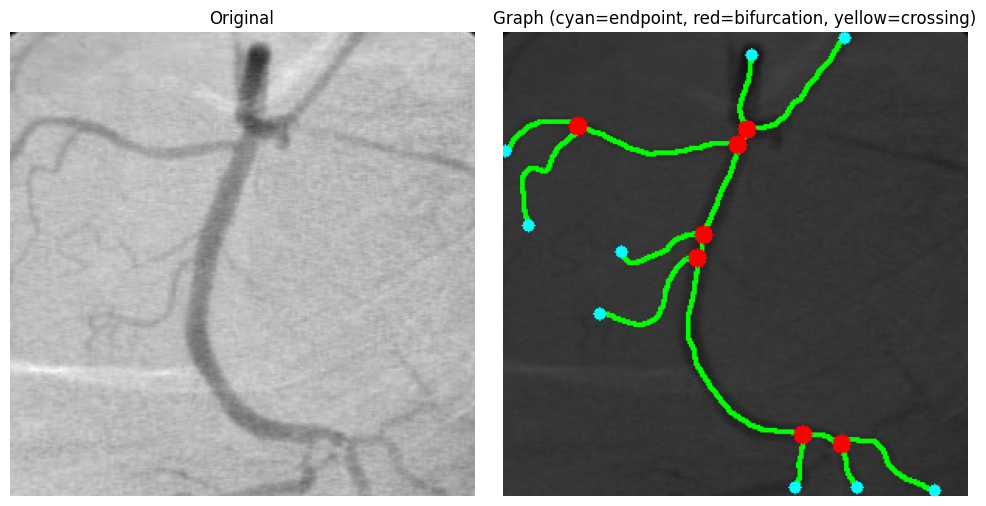

In [68]:
NODE_COLORS = {
    "endpoint": (0, 1, 1),
    "bifurcation": (1, 0, 0),
    "crossing": (1, 1, 0),
}

NODE_RADIUS = {
    "endpoint": 4,
    "bifurcation": 6,
    "crossing": 7,
}

vis_class = np.stack([image] * 3, axis=-1).astype(np.float32) / 255.0 * 0.4

for s, e in graph.edges():
    pts = graph[s][e]["pts"]
    for k in range(len(pts) - 1):
        cv2.line(
            vis_class,
            (int(pts[k, 1]), int(pts[k, 0])),
            (int(pts[k + 1, 1]), int(pts[k + 1, 0])),
            (0, 1, 0),
            2,
        )

for nid, data in graph.nodes(data=True):
    pos = data["o"]
    label = node_labels[nid]
    cv2.circle(
        vis_class,
        (int(pos[1]), int(pos[0])),
        NODE_RADIUS[label],
        NODE_COLORS[label],
        -1,
    )

show_image(
    image,
    vis_class,
    titles=["Original", "Graph (cyan=endpoint, red=bifurcation, yellow=crossing)"],
    cmap=["gray", None],
)